In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dry_Beans_Dataset.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()
df.info()
df.describe()
df.isnull()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13607,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13608,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13609,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

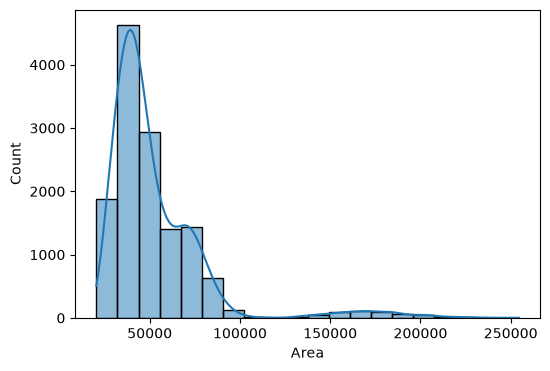

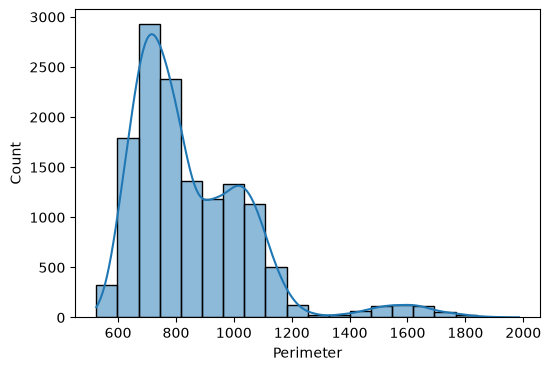

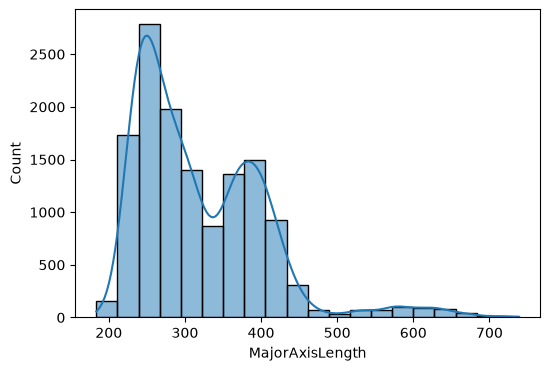

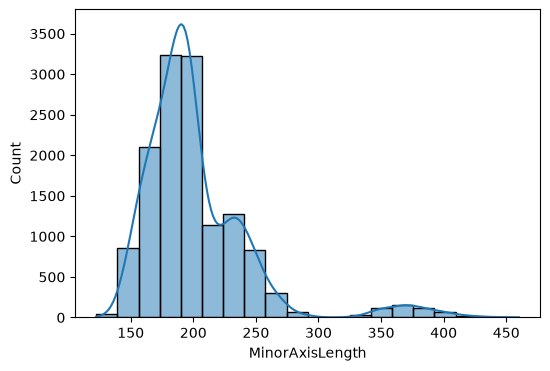

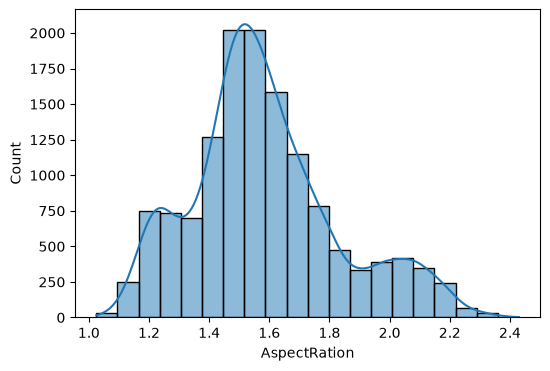

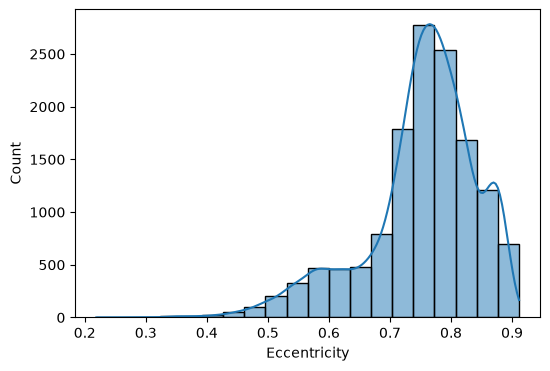

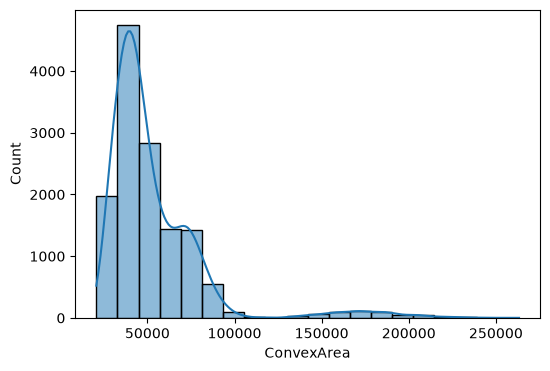

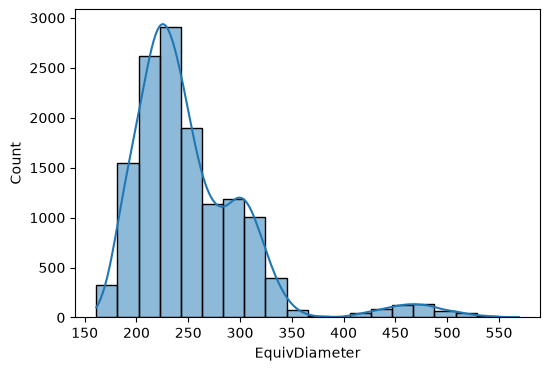

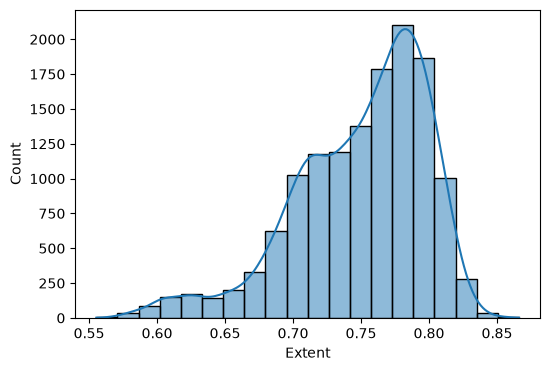

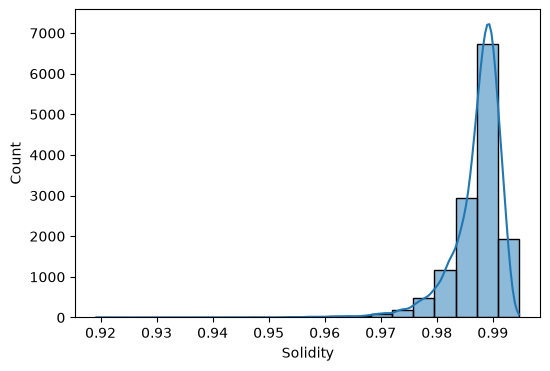

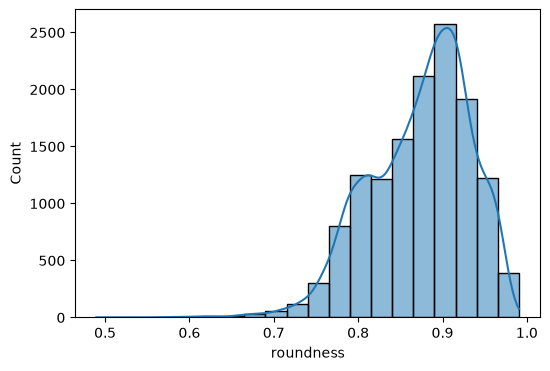

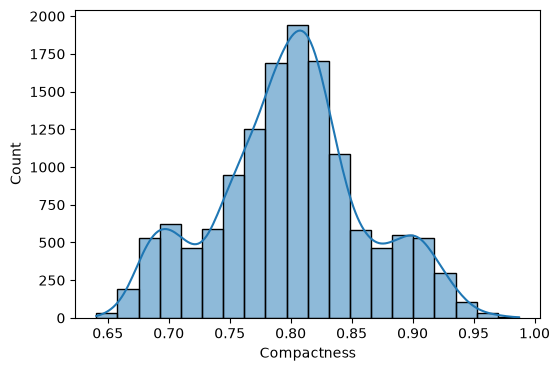

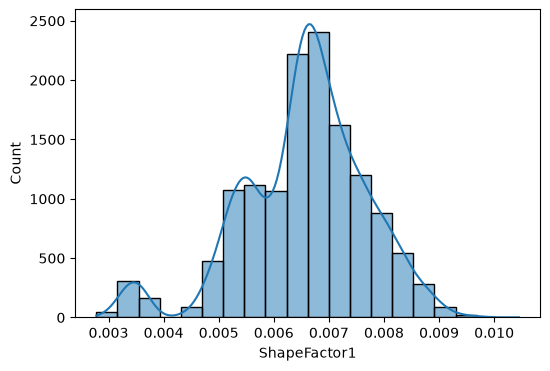

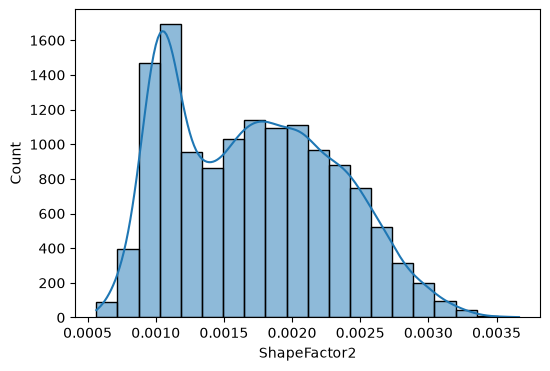

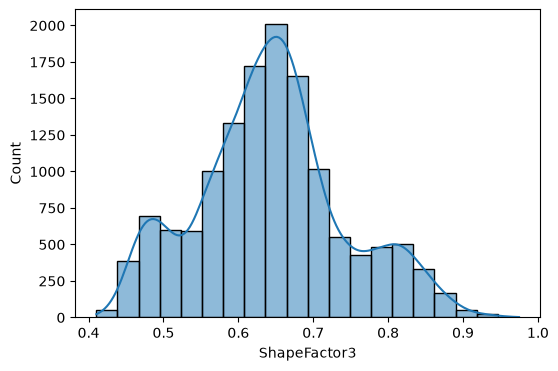

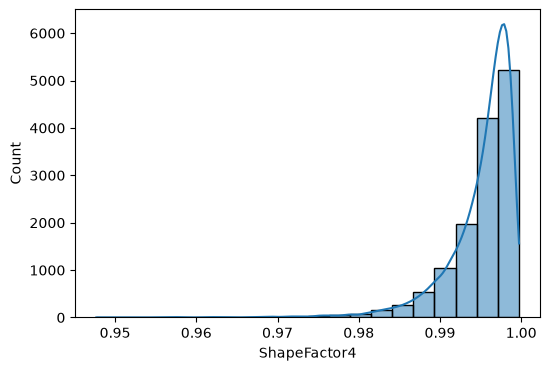

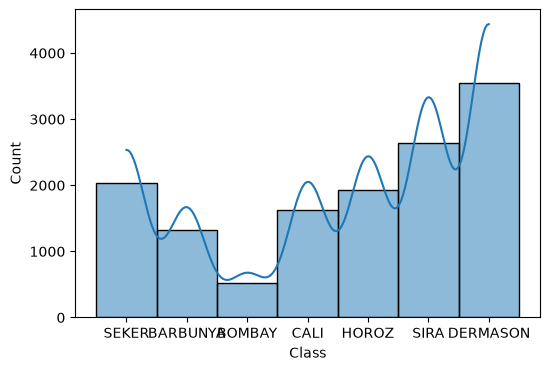

In [5]:
numeric_columns = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins = 20)

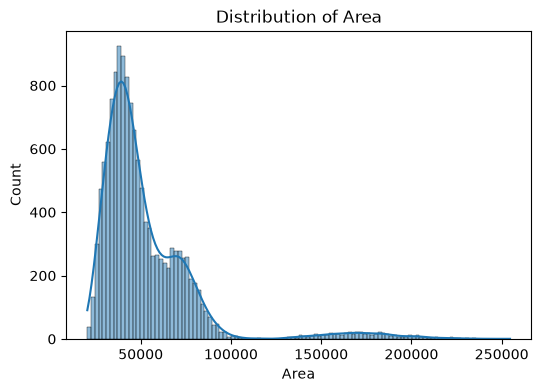

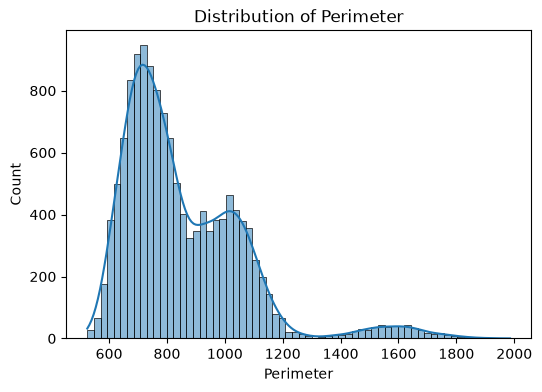

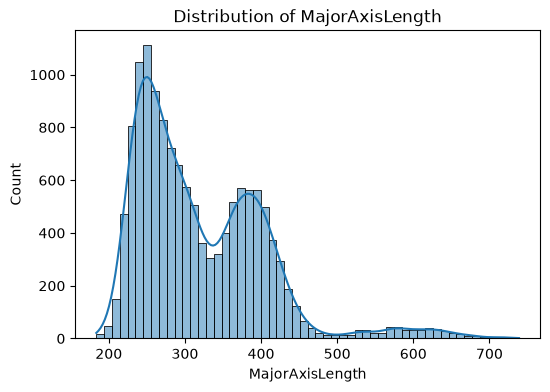

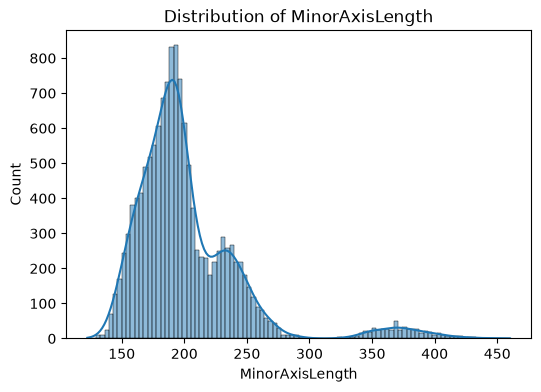

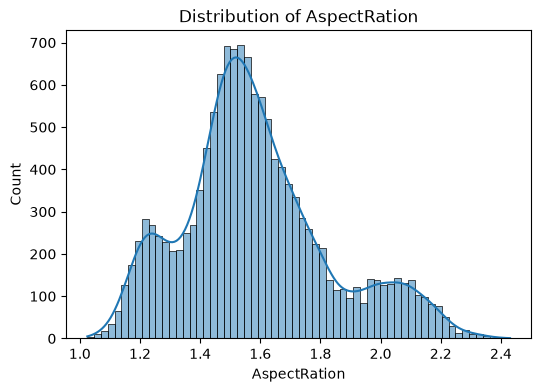

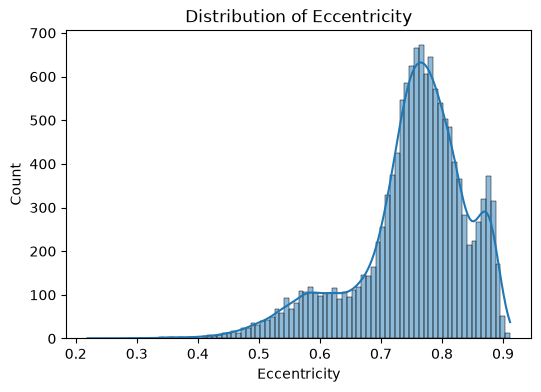

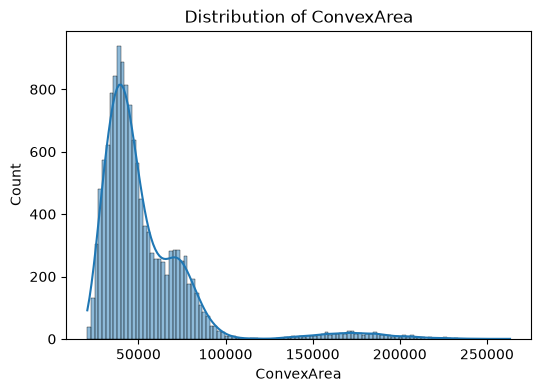

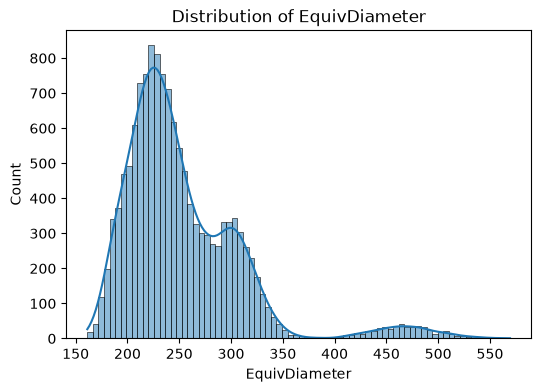

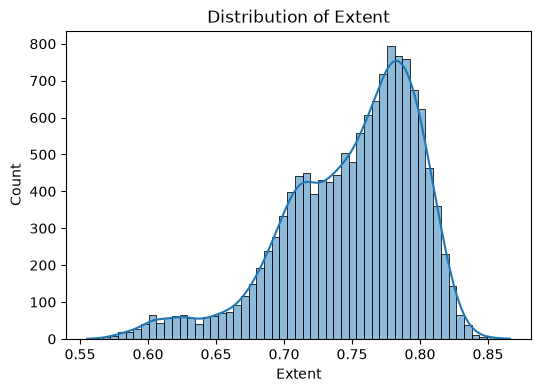

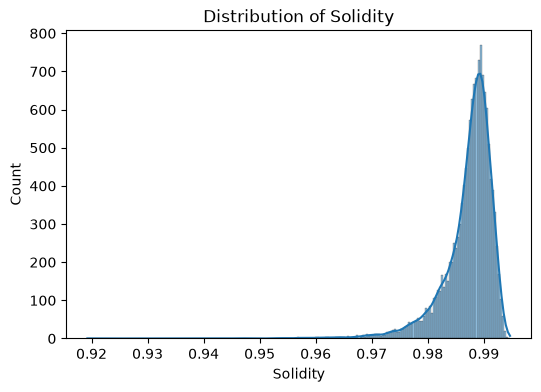

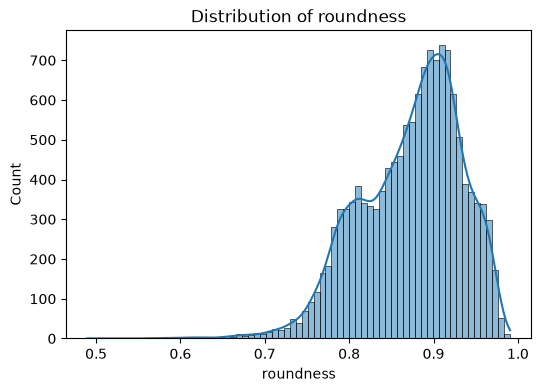

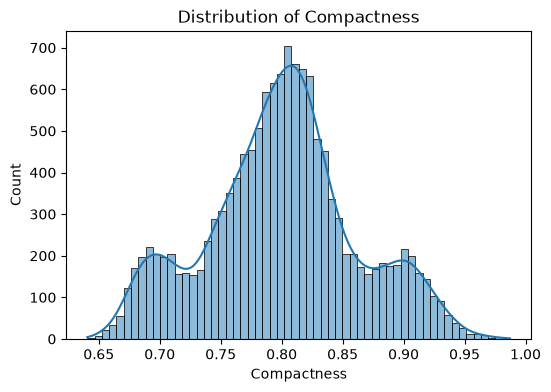

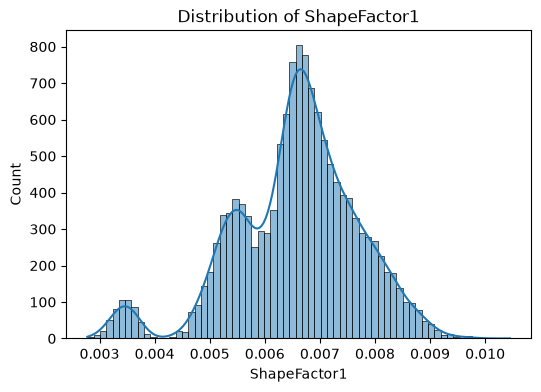

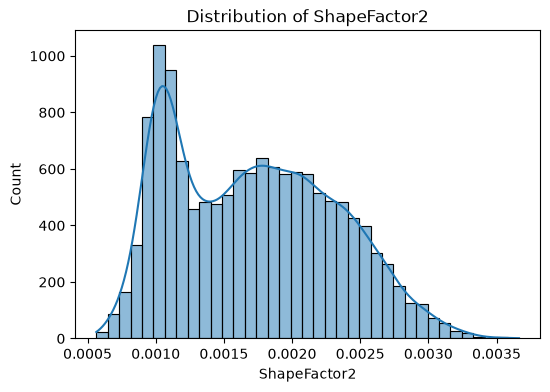

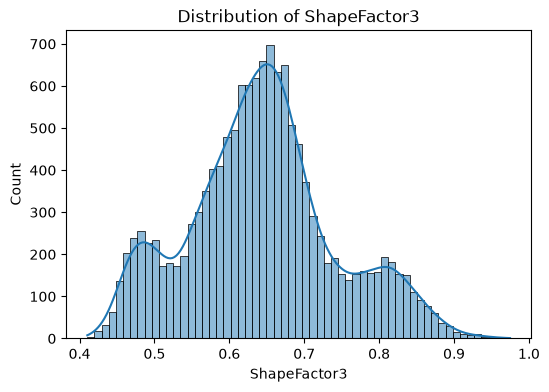

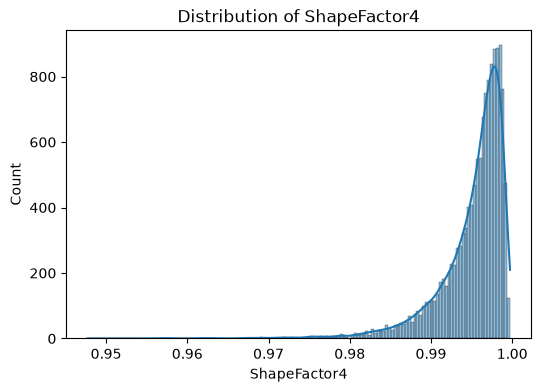

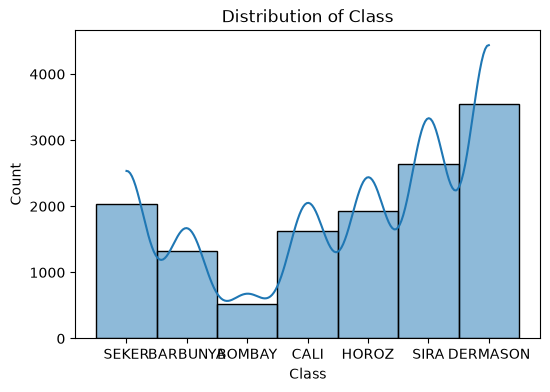

In [6]:
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(x=df[col], kde = True)
    plt.title(f"Distribution of {col}")
    plt.show()

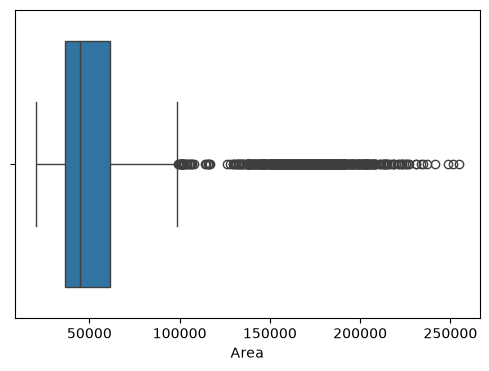

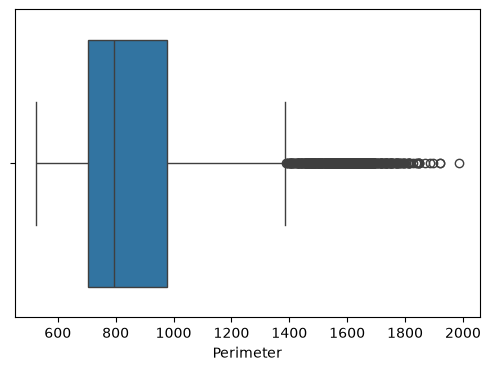

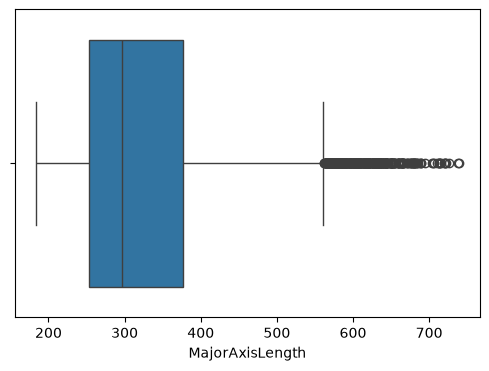

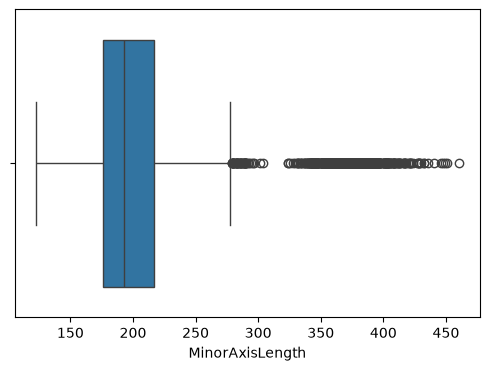

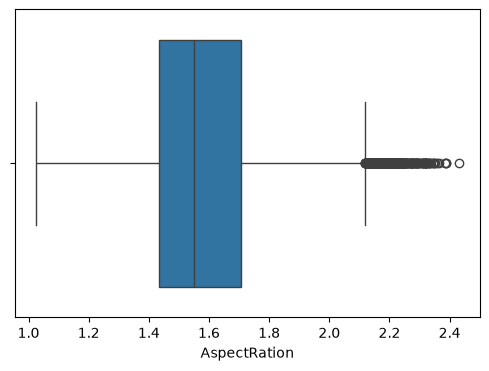

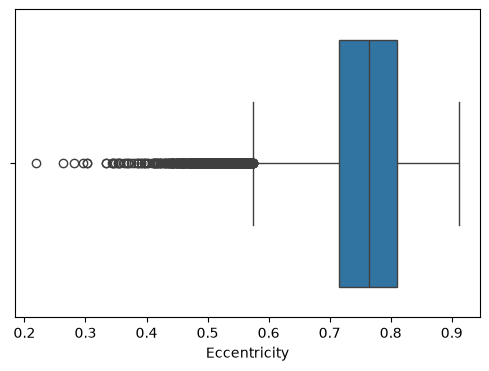

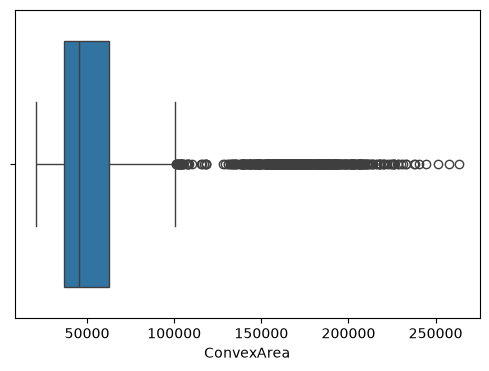

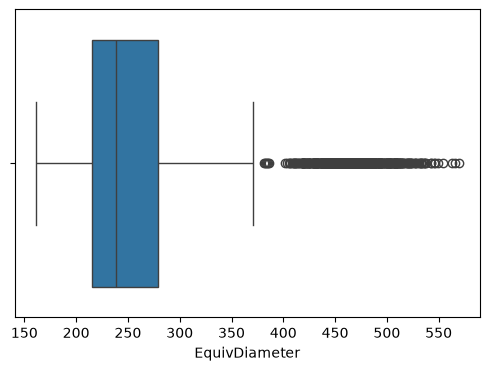

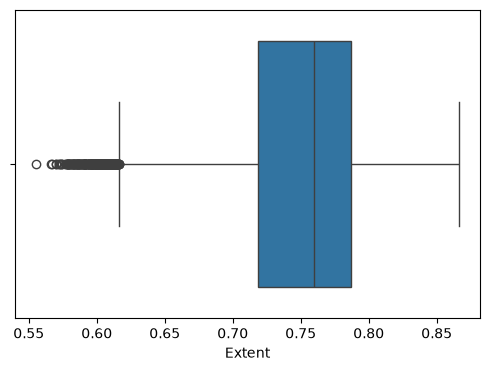

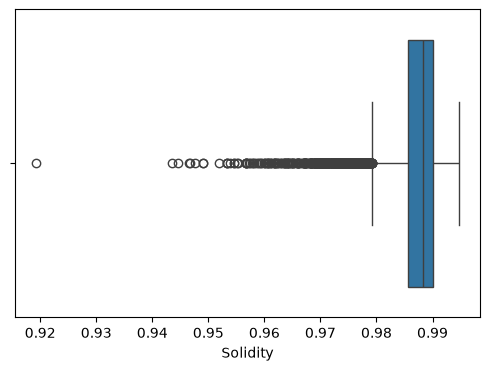

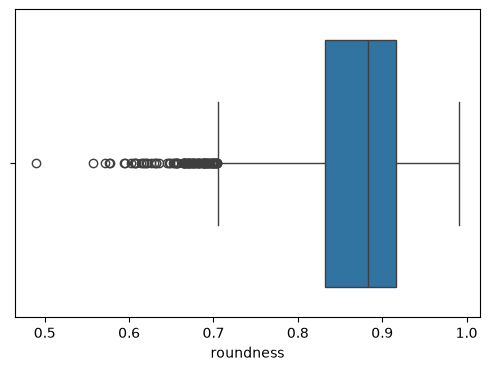

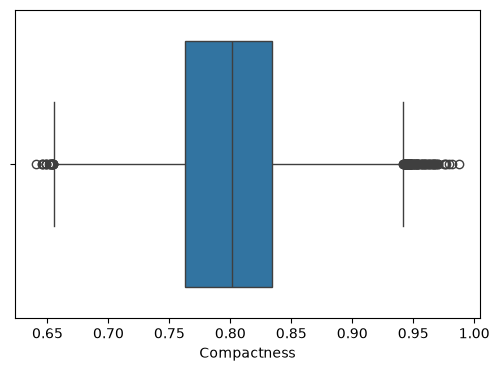

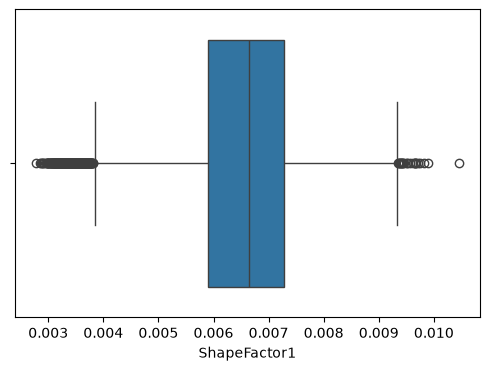

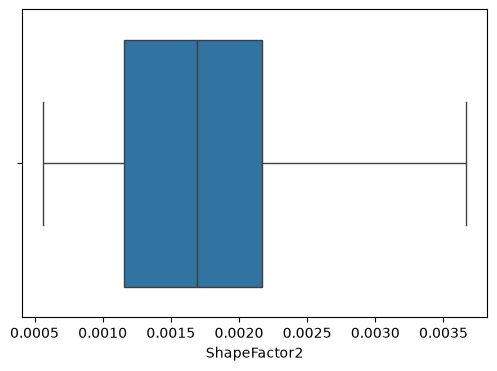

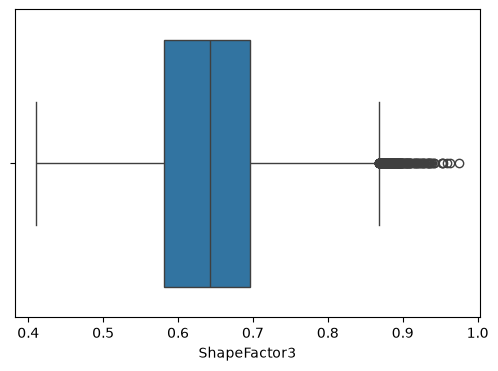

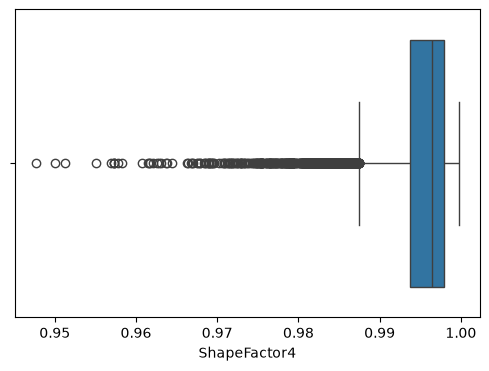

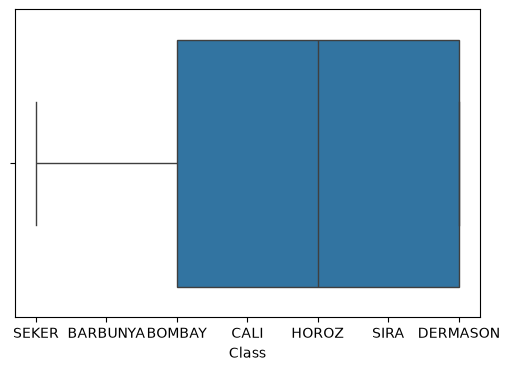

In [7]:
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x= df[col])

<Axes: >

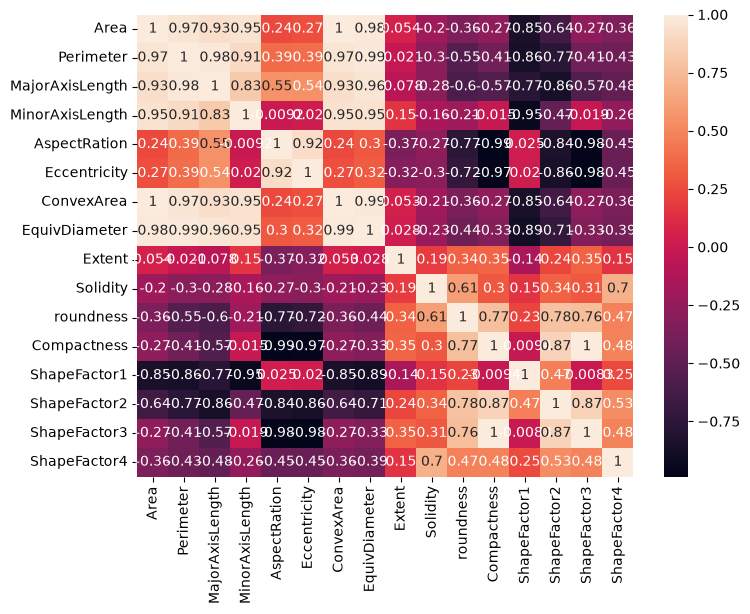

In [8]:
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True),annot = True) 

In [9]:
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    Q1 = df[col].astype(float).quantile(0.25)
    Q3 = df[col].astype(float).quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers found")

Area: 551 outliers found
Perimeter: 500 outliers found
MajorAxisLength: 379 outliers found
MinorAxisLength: 569 outliers found
AspectRation: 473 outliers found
Eccentricity: 843 outliers found
ConvexArea: 550 outliers found
EquivDiameter: 526 outliers found
Extent: 275 outliers found
Solidity: 778 outliers found
roundness: 91 outliers found
Compactness: 109 outliers found
ShapeFactor1: 533 outliers found
ShapeFactor2: 0 outliers found
ShapeFactor3: 195 outliers found
ShapeFactor4: 767 outliers found


In [10]:
df_capped = df.copy()
numeric_cols = df_capped.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df_capped[col].astype(float).quantile(0.25)
    Q3 = df_capped[col].astype(float).quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

df = df_capped


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
print("Class mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

Class mapping: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

skewed_cols = X.skew()[abs(X.skew()) > 1].index
for col in skewed_cols:
    X[col] = np.log1p(X[col])
print("Transformed skewed features:", list(skewed_cols))

Transformed skewed features: ['ShapeFactor4']


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [16]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [17]:
results_list = []
cv_scores_list = []
names = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    names.append(name)
    cv_scores_list.append(cv_scores)
    
    results_list.append({
        'Model': name,
        'CV Mean Acc': round(cv_scores.mean(), 4),
        'Test Acc': round(accuracy_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred, average='weighted'), 4)
    })

results_df = pd.DataFrame(results_list)
display(results_df)

,Model,CV Mean Acc,Test Acc,F1-Score
0,Logistic Regression,0.9247,0.9236,0.9237
1,Decision Tree,0.8938,0.8931,0.8928
2,Random Forest,0.9226,0.9221,0.9221
3,KNN,0.9208,0.9148,0.9150
4,SVM,0.9316,0.9247,0.9247
5,Naive Bayes,0.8980,0.8997,0.8999
6,AdaBoost,0.8307,0.8057,0.7893
7,Gradient Boosting,0.9251,0.9221,0.9221


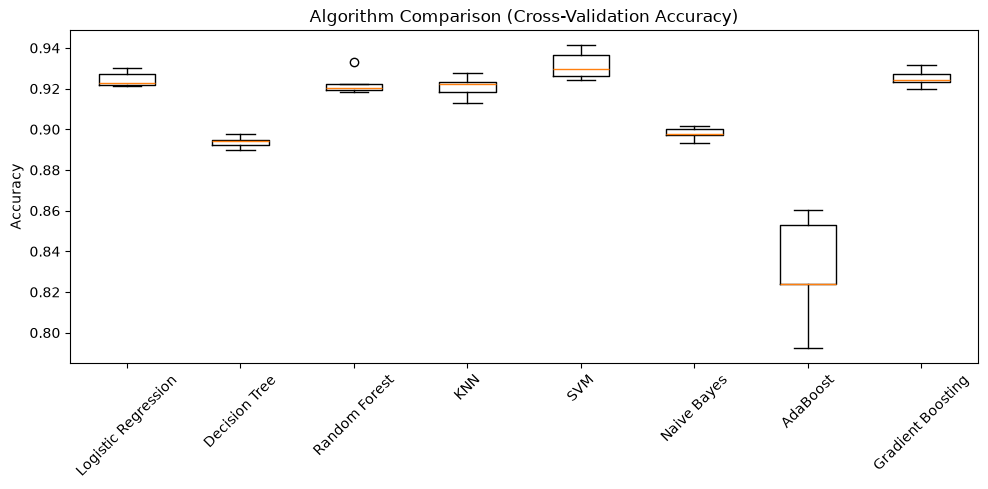

In [18]:
plt.figure(figsize=(10, 5))
plt.boxplot(cv_scores_list, tick_labels=names)
plt.title('Algorithm Comparison (Cross-Validation Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Class Distribution: {0: 1057, 1: 418, 2: 1304, 3: 2837, 4: 1542, 5: 1621, 6: 2109}


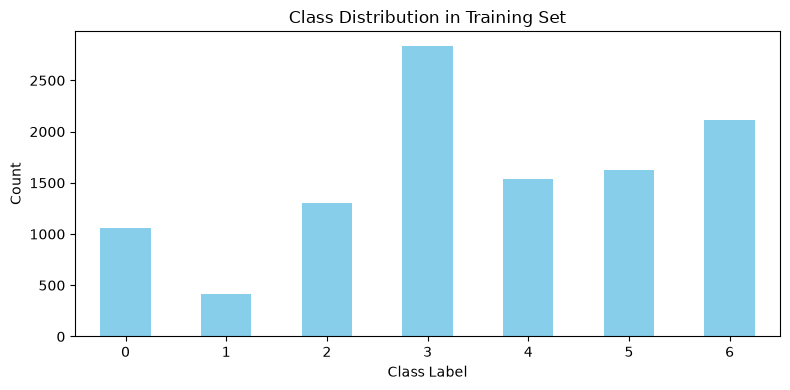

In [19]:
print("Class Distribution:", y_train.value_counts().sort_index().to_dict())
plt.figure(figsize=(8, 4))
y_train.value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


y_pred = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.92      0.92       709
           4       0.96      0.96      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [25]:
comparison_list = []

for name, model in models.items():
    if name != 'Random Forest (Tuned)':
        model.fit(X_train_scaled, y_train)
        
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred, average='weighted')
    
    overfitting = "Yes" if (train_acc - test_acc) > 0.05 else "No"
    
    comparison_list.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1 Score': round(f1, 4),
        'Overfitting (Y/N)': overfitting
    })

comparison_df = pd.DataFrame(comparison_list)
display(comparison_df)

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,Logistic Regression,0.9252,0.9236,0.9237,No
1,Decision Tree,1.0000,0.8931,0.8928,Yes
2,Random Forest,1.0000,0.9221,0.9221,Yes
3,KNN,0.9412,0.9148,0.9150,No
4,SVM,0.9341,0.9247,0.9247,No
5,Naive Bayes,0.8984,0.8997,0.8999,No
6,AdaBoost,0.8104,0.8057,0.7893,No
7,Gradient Boosting,0.9628,0.9221,0.9221,No


--- Class-wise Classification Report ---
              precision    recall  f1-score   support

           5       0.94      0.89      0.91       265
           0       1.00      1.00      1.00       104
           1       0.94      0.94      0.94       326
           2       0.91      0.92      0.91       709
           4       0.97      0.95      0.96       386
           6       0.94      0.96      0.95       406
           3       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



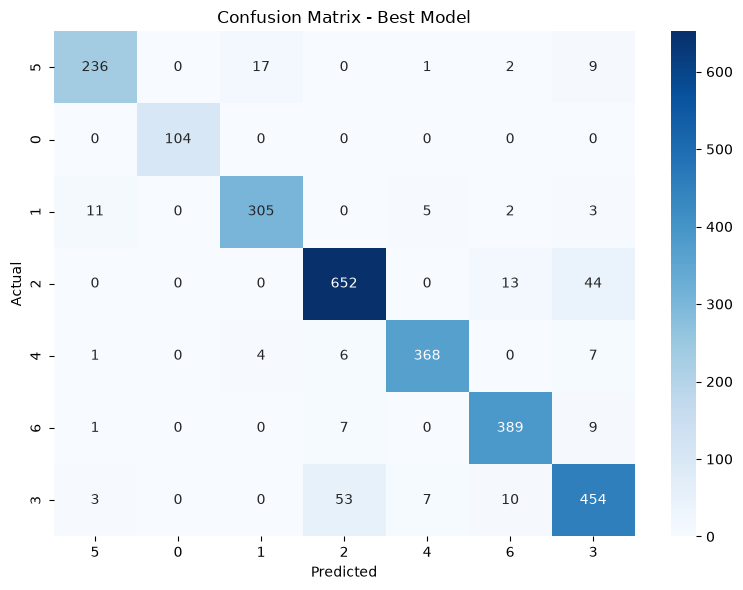

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = df['Class'].unique().astype(str)

y_pred_best = best_model.predict(X_test_scaled)

print("--- Class-wise Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
import joblib

joblib.dump(best_model, 'dry_bean_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(class_names, 'class_names.pkl')


['class_names.pkl']

In [29]:
import os
print(os.getcwd())

C:\Users\yachi\Downloads
